## Desarrollo tarea HW Sesión 3

Felipe López Vergara

## 1. Regresión Simple
 
# ¿Cómo se relaciona la volatilidad con los retornos del mercado?

La volatilidad del mercado se puede medir a traves del indice VIX que refleja la expectativa de volatilidad del mercado a 30 días. Los retornos del mercado se pueden medir a traves del indice S&P 500 (ticker en yahoo finance ^GSPC). El VIX (ticker en yahoo finance ^VIX) es conocido como el índice del miedo porque cuando sube, los inversionistas esperan más incertidumbre o caídas en el mercado. Para responder la pregunta anterior, se puede realizar una regresión lineal simple entre la volatilidad del mercado y los retornos del mercado.


Delta VIX_t =\\alfa +\\beta\\cdot r_{\\texto{SP500}, t} +\\varepsilon_t

Entender esta relacion es crucial para los inversionistas, ya que les permite anticipar movimientos del mercado y ajustar sus estrategias de inversión en consecuencia., por otro lado, ayuda a entender el comportamiento del mercado en periodos de stress.

Con la información anterior, debe hacer los siguientes pasos:

In [28]:
from matplotlib import pyplot as plt 
import statsmodels.api as sm
import pandas as pd 
import seaborn as sns
import yfinance as yf
import numpy as np

sns.set_style("dark")

1.Considere al menos 10 años de historia (frecuencia mensual) de los índices VIX y S&P 500.

In [ ]:
#Descarga precios del VIX y el S&P 500 desde Yahoo Finance.

vix = yf.download('^VIX', start = '2016-01-01', end = '2026-01-01', progress = False)['Close']
sp500 = yf.download('^GSPC', start = '2016-01-01', end = '2026-01-01', progress = False)['Close']

#Frecuencia mensual
vix_mensual = vix.resample('ME').last()
sp500_mensual = sp500.resample('ME').last().pct_change()


2. Realice un scatterplot para visualizar la relación entre los dos índices e interprete lo que observa.

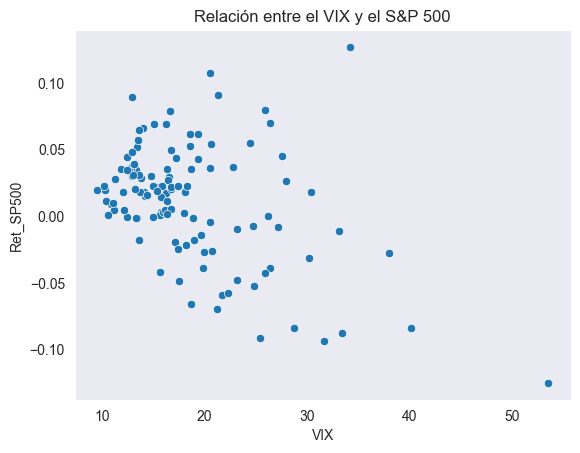

In [46]:
# Relación entre el VIX y el S&P 500

vix_mensual = vix_mensual.copy(); vix_mensual.name = 'VIX'
sp500_mensual = sp500_mensual.copy(); sp500_mensual.name = 'Ret_SP500'

data = pd.concat([vix_mensual, sp500_mensual], axis = 1).dropna()
data.columns = ['VIX', 'Ret_SP500']
data = data.reset_index(drop = True)

data.head()
sns.scatterplot(x = 'VIX', y = 'Ret_SP500', data = data)
plt.title('Relación entre el VIX y el S&P 500')
plt.show()

La relación del índice VIX que mide la volatilidad esperada del índice S&P 500 y el retorno del S&P 500 es inversamente proporcional o tiene una correlación inversa, cuando disminuye el índice bursátil S&P 500 quiere decir que existe un aumento en la volatilidad e incertidumbre del mercado por lo que el índice VIX aumenta. Se observa además que la concentración de puntos se encuentra bajo el umbral de los 20 puntos porcentuales del índice VIX que indica tranquilidad en el mercado.

Estime un modelo de regresión simple entre la volatilidad del mercado y los retornos del mercado

In [ ]:
#